# Program - plot-var_2d_time_lev-cn_xy_flexible-TaiESM_hindcast

**Purpose**

read TaiESM hindcast data and make plots for time-level dimension, including contour, time series, and profiles.

**Content**
- read data: Read TaiESM hindcast data at a grid point (lat, lon) and selected time range 
- set characteristics for plots, such as time tick mark labels, color map, etc.
- plot time series (xy_series)
- plot profiles for N variables at one time step (xy_profile_Nv1t)
- plot profiles for 1 variable at multiple time step (xy_profile_1vNt)
- plot time-level cross section (cn_time_level)

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 
March 2025

**Reference program:**
Thanks for chatGPT.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## ----- read data -----

## select_region_ds

In [2]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="lat_lon", lat=lat, lon=lon)

#ds1_region

## lat_lon_weighted_avg

In [3]:
import xarray as xr
import numpy as np

def lat_lon_weighted_avg(ds: xr.Dataset, lat_name: str = 'lat', lon_name: str = 'lon') -> xr.Dataset:
    """
    Compute the latitude-weighted average of an xarray.Dataset over lat and lon dimensions,
    only for variables that have both lat and lon in their coordinates.
    
    Parameters:
    ds (xr.Dataset): Input dataset with latitude and longitude dimensions.
    lat_name (str): Name of the latitude coordinate in the dataset.
    lon_name (str): Name of the longitude coordinate in the dataset.
    
    Returns:
    xr.Dataset: Dataset with lat/lon dimensions averaged using latitude weighting.
    """
    # Select only numeric variables that have both lat and lon as dimensions
    valid_vars = {
        var: ds[var] for var in ds.data_vars
        if np.issubdtype(ds[var].dtype, np.number) and {lat_name, lon_name}.issubset(ds[var].dims)
    }
    
    if not valid_vars:
        raise ValueError("No valid variables found with both lat and lon dimensions.")
    
    ds = xr.Dataset(valid_vars, coords=ds.coords)
    
    # Convert latitudes to radians for weighting
    lat_rad = np.deg2rad(ds[lat_name])
    
    # Compute latitude weights (cosine of latitude)
    weights = np.cos(lat_rad)
    
    # Normalize weights only over lat dimension
    weights /= weights.sum(dim=lat_name)
    
    # Compute weighted mean using dot product for efficiency
    weighted_mean = ds.weighted(weights).mean(dim=[lat_name, lon_name])
    
    return weighted_mean


## read_hindcast_icdate_lat_lon

In [4]:
def assign_ds_attrs(ds: xr.Dataset,
                    region, lat_values, lon_values):
    ds = ds.assign_attrs(
        avg_region=region,
        avg_lat=lat_values,
        avg_lon=lon_values,
    )
    return ds

def read_hindcast_icdate_lat_lon(icdate, 
    icdata_option = "ERA5", 
    ss5="00000",
    region=None,
    lat=None, lon=None,
    ):

    file_dates = 5

    #--- read datasets
    choice = "custom_Ttend_3hr"
    ds_Ttend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_state_3hr"
    ds_state = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_Qtend_3hr"
    ds_Qtend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    choice = "custom_2d_1hr"
    ds_2d = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, icdata_option=icdata_option, file_dates=file_dates, ss5=ss5)

    #--- diagnose variables in all ds
    yhc.diagnose_var(ds_state, ["play","plev","Z3_ilev"])
    yhc.diagnose_var(ds_Ttend, ["DT_SUM_PHYS", "DT_deep"])
    yhc.diagnose_var(ds_Qtend, ["DQV_SUM_PHYS", "DQL_SUM_PHYS", "DQV_deep", "DQV_SUM_PHYS_no_MA_VD", "DQL_SUM_PHYS_no_MA_VD" ])

    #--- get data at the given lat/lon
    ds_Ttend_latlon = select_region_ds(ds_Ttend, region=region, lat=lat, lon=lon)
    ds_Qtend_latlon = select_region_ds(ds_Qtend, region=region, lat=lat, lon=lon)
    ds_state_latlon = select_region_ds(ds_state, region=region, lat=lat, lon=lon)
    ds_1d_time_latlon = select_region_ds(ds_2d, region=region, lat=lat, lon=lon)

    lat_values = ds_state_latlon['lat'].values.tolist()
    lon_values = ds_state_latlon['lon'].values.tolist()

    if region != "lat_lon":        
        ds_state_latlon = lat_lon_weighted_avg(ds_state_latlon)
        ds_state_latlon = assign_ds_attrs(ds_state_latlon, region, lat_values, lon_values)
        ds_Ttend_latlon = lat_lon_weighted_avg(ds_Ttend_latlon)
        ds_Ttend_latlon = assign_ds_attrs(ds_Ttend_latlon, region, lat_values, lon_values)
        ds_Qtend_latlon = lat_lon_weighted_avg(ds_Qtend_latlon)
        ds_Qtend_latlon = assign_ds_attrs(ds_Qtend_latlon, region, lat_values, lon_values)
        ds_1d_time_latlon = lat_lon_weighted_avg(ds_1d_time_latlon)
        ds_1d_time_latlon = assign_ds_attrs(ds_1d_time_latlon, region, lat_values, lon_values)
    
    return ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon

#-----------
# do_test
#-----------

do_test="112"
#do_test=False

if (do_test == "111"):
    icdate = "20010707" ; ss5="00000"
    #icdate = "20010711" ; ss5="43200"

    #region = "DYCOMS"

    region = "lat_lon" ; lat=30 ; lon=240
    #ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate, region=region)
    icdata_option = "qq02_macrop_tpdf"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(icdate, icdata_option=icdata_option, 
                                                                                                        region=region, lat=lat, lon=lon, ss5=ss5)

#ds_state_latlon
#ds_Ttend_latlon
#ds_Qtend_latlon
#ds_1d_time_latlon

#pp = yhc.get_area_avg(ds_state_latlon, region="DYCOMS")

## get_ds_time_level_2d_vars_for_xy_plot

In [5]:
import cftime

###############
###############
###############
class read_hindcast_data:
    def __init__(self, icdate, icdata_option="ERA5", ss5="00000", region=None, lat=None, lon=None):
        """
        Initialize the object with initial datasets based on the provided initial conditions (icdate), 
        latitude (lat), and longitude (lon).
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - icdata_option: Option for selecting hindcast data (string, default="ERA5")
        - region: Region identifier for the dataset (string, optional)
        - lat: Latitude coordinate for the data (float, optional)
        - lon: Longitude coordinate for the data (float, optional)
        """
        self.icdata_option = icdata_option  # Store the icdata_option
        self.region = region  # Store the region
        self.datasets = {}  # Store datasets in a dictionary
        self.load_data(icdate, lat, lon)  # Load initial datasets

    def load_data(self, icdate, lat, lon):
        """
        Load datasets dynamically using the given initial condition date, latitude, and longitude. 
        The datasets are retrieved and stored in the `self.datasets` dictionary.
        
        Args:
        - icdate: The initial condition date for the hindcast (string or datetime)
        - lat: Latitude coordinate for the data (float)
        - lon: Longitude coordinate for the data (float)
        """
        try:
            # Retrieve data from the hindcast based on the given initial conditions
            ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon, ds_1d_time_latlon = read_hindcast_icdate_lat_lon(
                icdate, ss5=ss5, icdata_option=self.icdata_option, region=self.region, lat=lat, lon=lon,
            )
            
            # Store the datasets in the dictionary
            self.datasets["ds_state"] = ds_state_latlon  # Main state dataset
            self.datasets["ds_Ttend"] = ds_Ttend_latlon  # Temperature tendency dataset
            self.datasets["ds_Qtend"] = ds_Qtend_latlon  # Q tendency dataset
            self.datasets["ds_1d_time"] = ds_1d_time_latlon  # Q tendency dataset
            self.datasets["play"] = ds_state_latlon["play"]  # Play variable from state dataset
            self.datasets["Z3"] = ds_state_latlon["Z3"]  # Store "Z3" from state dataset
            self.datasets["plev"] = ds_state_latlon["plev"]  # Store "Z3" from state dataset
            self.datasets["Z3_ilev"] = ds_state_latlon["Z3_ilev"]  # Store "Z3" from state dataset

            # add new attributes
            self.datasets["play"].attrs["coord_label"] = "Pressure (hPa)"
            self.datasets["play"].attrs["do_inverse_yaxis"] = True
            self.datasets["plev"].attrs["coord_label"] = "Pressure (hPa)"
            self.datasets["plev"].attrs["do_inverse_yaxis"] = True
            
            self.datasets["Z3"].attrs["coord_label"] = "Altitude (m)"
            self.datasets["Z3"].attrs["do_inverse_yaxis"] = False
            self.datasets["Z3_ilev"].attrs["coord_label"] = "Altitude (m)"
            self.datasets["Z3_ilev"].attrs["do_inverse_yaxis"] = False
        
        except Exception as e:
            print(f"Error loading data: {e}")  # Error handling if data loading fails
            self.datasets = {}  # Reset the datasets in case of an error

    def get(self, data):
        """
        Retrieve a specific dataset by name.

        Args:
        - data: The name of the dataset to retrieve (string)
        
        Returns:
        - The requested dataset or None if the dataset is not found.
        """
        return self.datasets.get(data, None)

    def set(self, key, value):
        """
        Modify or add a dataset to the dictionary dynamically.

        Args:
        - key: The name of the dataset (string)
        - value: The dataset value (object)
        """
        self.datasets[key] = value  # Add or update the dataset in the dictionary

###############
###############
###############
def select_ds_time_period(ds_dict, lev_dict, start_str=None, end_str=None):
    """
    Selects data from a dictionary of xarray Datasets within a specified time period.

    Parameters:
        ds_dict (dict): A dictionary of xarray Datasets, where each dataset contains a 'time' coordinate in cftime.DatetimeNoLeap format.
        start_str (str): Start time in "YYYYMMDD_HHMMSS" format.
        end_str (str): End time in "YYYYMMDD_HHMMSS" format.

    Returns:
        dict: A dictionary of xarray Datasets within the specified time range.
    """

    # Assuming all datasets in ds_dict have the same time range, get the global time range from one of them
    time_min, time_max = ds_dict[next(iter(ds_dict))].time.min().item(), ds_dict[next(iter(ds_dict))].time.max().item()

    # Check if the start_str and end_str are provided
    if start_str:
        # Parse start time from "YYYYMMDD_HHMMSS" format
        start_time = cftime.DatetimeNoLeap(
            int(start_str[:4]),  # Year
            int(start_str[4:6]),  # Month
            int(start_str[6:8]),  # Day
            int(start_str[9:11]),  # Hour
            int(start_str[11:13]),  # Minute
            int(start_str[13:15])   # Second
        )

        # Validate start_time within dataset range
        if start_time < time_min or start_time > time_max:
            raise ValueError(f"start_str ({start_str}) is out of range: {time_min} to {time_max}")
    else:
        start_time = time_min  # Default to minimum time in dataset if start_str is not provided

    if end_str:
        # Parse end time from "YYYYMMDD_HHMMSS" format
        end_time = cftime.DatetimeNoLeap(
            int(end_str[:4]),  # Year
            int(end_str[4:6]),  # Month
            int(end_str[6:8]),  # Day
            int(end_str[9:11]),  # Hour
            int(end_str[11:13]),  # Minute
            int(end_str[13:15])   # Second
        )

        # Validate end_time within dataset range
        if end_time < time_min or end_time > time_max:
            raise ValueError(f"end_str ({end_str}) is out of range: {time_min} to {time_max}")
    else:
        end_time = time_max  # Default to maximum time in dataset if end_str is not provided

   # Check if end_time is greater than start_time
    if end_time < start_time:
        raise ValueError(f"end_time ({end_time}) cannot be earlier than start_time ({start_time})")
        
    # Apply the time selection to each dataset in the dictionary and return the updated dictionary
    ds_dict_filtered = {key: ds.sel(time=slice(start_time, end_time)) for key, ds in ds_dict.items()}
    lev_dict_filtered = {key: lev.sel(time=slice(start_time, end_time)) for key, lev in lev_dict.items()}

    return ds_dict_filtered, lev_dict_filtered

###############
###############
###############
def select_lev_range_old(ds_dict, lev_dict, lev_select=None, lev_min=None, lev_max=None):
    """
    Filters datasets within a specified lev range based on a selected variable from lev_dict.

    Parameters:
        ds_dict (dict): Dictionary containing the datasets (e.g., 'ds_state', 'ds_Ttend').
        lev_dict (dict): Dictionary containing the variables like 'play', 'Z3'.
        lev_select (str): Select which variable from lev_dict to use ('play' or 'Z3').
        lev_min (float): Minimum lev value for filtering.
        lev_max (float): Maximum lev value for filtering.

    Returns:
        tuple: Filtered ds_dict and lev_dict.
    """

    if lev_min is not None and lev_max is not None:
        # Check which variable to use for filtering
        if lev_select == "pressure":
            mask_lev = (lev_dict["play"] > lev_min) & (lev_dict["play"] < lev_max)
            mask_ilev = (lev_dict["plev"] > lev_min) & (lev_dict["plev"] < lev_max)

        elif lev_select == "play":
            mask = (lev_dict["play"] > lev_min) & (lev_dict["play"] < lev_max)
        elif lev_select == "plev":
            mask = (lev_dict["plev"] > lev_min) & (lev_dict["plev"] < lev_max)
        elif lev_select == "Z3":
            mask = (lev_dict["Z3"] > lev_min) & (lev_dict["Z3"] < lev_max)
        elif lev_select == "Z3_ilev":
            mask = (lev_dict["Z3_ilev"] > lev_min) & (lev_dict["Z3_ilev"] < lev_max)
        else:
            raise ValueError(f"Invalid lev_select value: {lev_select}. Must be ('play', 'plev', 'Z3', 'Z3_ilev'")
        
        # Compute the mask if it's a dask array
        mask_lev_computed  = mask_lev.compute()  # Eager evaluation
        lev_indices = mask_lev_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values

        # Compute the mask if it's a dask array
        mask_ilev_computed  = mask_ilev.compute()  # Eager evaluation
        ilev_indices = mask_ilev_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        ilev_values_to_select = lev_dict["plev"].ilev.values[ilev_indices]  # Get lev values

        lev_dict_filtered = {
            key: (
                val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" 
                else val.sel(ilev=lev_values_to_select) if key == "plev" or key == "Z3_ilev" 
                else val
            )
            for key, val in lev_dict.items()
                            }
            #print(ds_dict.items

        ds_dict_filtered = ds_dict.copy()
        
        if lev_select == "play" or lev_select == "Z3":
            lev_indices = mask_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
            lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values from play or Z3

            ds_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in ds_dict.items()}
            lev_dict_filtered = {
                key: (
                    val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" 
                    else val.sel(ilev=ilev_values_to_select) if key == "plev" or key == "Z3_ilev" 
                    else val
                )
                for key, val in lev_dict.items()
                                }
            #lev_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in lev_dict.items()}   
            #lev_dict_filtered = {key: (val.sel(lev=lev_values_to_select) if key == "play" or key == "Z3" else val) for key, val in lev_dict.items()}
            
            #ds_dict_filtered = ds_dict.copy()
            #lev_dict_filtered = lev_dict.copy()
        
        # Get lev indices where the condition is True across all time points
        #if lev_select == "play" or lev_select == "Z3":
         #   lev_indices = mask_computed.any(dim='time')  # Boolean array (lev,) for condition across all time
        #lev_indices 
        
        # Extract the lev values that match the condition
        #lev_values_to_select = lev_dict["play"].lev.values[lev_indices]  # Get lev values from play or Z3
        #ilev_values_to_select = lev_dict["plev"].ilev.values[ilev_indices]  # Get lev values from play or Z3
    
        # Apply filtering to the datasets using the lev values
        #if lev_select == "play" or lev_select == "Z3":
        #    ds_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in ds_dict.items()}
        #    lev_dict_filtered = {key: val.sel(lev=lev_values_to_select) for key, val in lev_dict.items()}
        #elif lev_select == "plev" or lev_select == "Z3_ilev":
        #    ds_dict_filtered = {key: val.sel(ilev=ilev_values_to_select) for key, val in ds_dict.items()}
        #    lev_dict_filtered = {key: val.sel(ilev=ilev_values_to_select) for key, val in lev_dict.items()}
        
        return ds_dict_filtered, lev_dict_filtered
    else:
        return ds_dict, lev_dict

###############
###############
###############
def select_lev_range(ds_dict, lev_dict, lev_select=None, lev_coord='lev', lev_min=None, lev_max=None):
    """
    Filters datasets within a specified lev range based on a selected variable from lev_dict.

    Parameters:
        ds_dict (dict): Dictionary containing the datasets (e.g., 'ds_state', 'ds_Ttend').
        lev_dict (dict): Dictionary containing the variables like 'play', 'Z3'.
        lev_select (str): Select which variable from lev_dict to use ('play' or 'Z3').
        lev_coord (str): The coordinate to filter on, either 'lev' or 'ilev'.
        lev_min (float): Minimum lev value for filtering.
        lev_max (float): Maximum lev value for filtering.

    Returns:
        tuple: Filtered ds_dict and lev_dict.
    """

    if lev_min is not None and lev_max is not None:
        # Check if lev_select exists in lev_dict
        if lev_select not in lev_dict:
            raise ValueError(f"Selected variable {lev_select} is not present in lev_dict.")
        
        # Check if the selected coordinate exists in lev_dict[lev_select]
        if lev_coord not in lev_dict[lev_select].coords:
            raise ValueError(f"Coordinate '{lev_coord}' is not present in the selected variable '{lev_select}'.")

        # Get lev values
        lev_values = lev_dict[lev_select].values

        # Apply the mask to get a boolean array (time, lev or ilev)
        mask = (lev_values > lev_min) & (lev_values < lev_max)

        # Reduce across the time dimension to find the valid levels
        lev_indices_to_select = np.any(mask, axis=0)  # Boolean array for each lev dimension
        selected_lev_indices = np.where(lev_indices_to_select)[0]  # Indices of levs that pass the condition

        # Filter datasets, only if they have the specified lev_coord dimension
        ds_dict_filtered = {
            key: (val.isel({lev_coord: selected_lev_indices}) if lev_coord in val.dims else val) 
            for key, val in ds_dict.items()
        }

        # Filter lev_dict similarly
        lev_dict_filtered = {
            key: (val.isel({lev_coord: selected_lev_indices}) if lev_coord in val.dims else val) 
            for key, val in lev_dict.items()
        }

        return ds_dict_filtered, lev_dict_filtered

    else:
        return ds_dict, lev_dict

###############
###############
###############
def get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option="ERA5",
                                          ss5="00000", 
                                          region=None, lat=None, lon=None,
                                         lev_select=None, lev_min=None, lev_max=None,
                                         start_str=None, end_str=None,
                                         ):
    """
    Retrieve datasets containing variables with 2D dimensions [time, level] for use in XY plots.
    The function returns datasets for key variables such as state, Ttend, Qtend, and other related variables 
    like play and Z3.

    Args:
    - icdate: The initial condition date for the hindcast (string or datetime)
    - lat: Latitude coordinate for the data (float)
    - lon: Longitude coordinate for the data (float)

    Returns:
    - ds_dict: Dictionary containing the primary datasets (state, Ttend, Qtend)
    - lev_dict: Dictionary containing additional variables for XY plot (play, Z3)
    """

    func_name = "get_ds_time_level_2d_vars_for_xy_plot"
    
    # Create an instance of the read_hindcast_data class
    hindcast_data = read_hindcast_data(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon)

    # Retrieve the datasets for main variables
    ds_dict = {
        "state": hindcast_data.get("ds_state"),  # Main state dataset
        "Ttend": hindcast_data.get("ds_Ttend"),  # Temperature tendency dataset
        "Qtend": hindcast_data.get("ds_Qtend"),  # Q tendency dataset
        "1d_time": hindcast_data.get("ds_1d_time"),  # time series dataset
    }

    # Additional variables for XY plot
    lev_dict = {
        "play": hindcast_data.get("play"),  # Play variable for plotting
        "plev": hindcast_data.get("plev"),  # Play variable for plotting
        "Z3": hindcast_data.get("Z3"),  # Z3 variable for plotting
        "Z3_ilev": hindcast_data.get("Z3_ilev"),  # Z3 variable for plotting

    }

    # select level range
    if (lev_select == "play"):
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "play", lev_coord="lev", lev_min=lev_min, lev_max=lev_max)
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "plev", lev_coord="ilev", lev_min=lev_min, lev_max=lev_max)
    elif (lev_select == "Z3"):
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "Z3", lev_coord="lev", lev_min=lev_min, lev_max=lev_max)
        ds_dict, lev_dict = select_lev_range(ds_dict, lev_dict, lev_select = "Z3_ilev", lev_coord="ilev", lev_min=lev_min, lev_max=lev_max)        
    elif (lev_select is None):
        pass
    else:
        raise ValueError(f"[{func_name}]: Invalid lev_select value: {lev_select}. Must be 'play' or 'Z3'.")
    
    # select time range
    ds_dict, lev_dict = select_ds_time_period(ds_dict, lev_dict, start_str=start_str, end_str=end_str)

    return ds_dict, lev_dict

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    #icdate = "20010711" ; ss5="43200"
    icdate = "20010707" ; ss5="00000"

    #region="lat_lon" ; lat = 31.5 ; lon = 236.5
    region = "DYCOMS"
    icdata_option = "qq02_macrop_park"
    
    # select all time and lev
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, region=region, lat=lat, lon=lon)

    # select lev range
    lev_select = "Z3" ; lev_max = 3000 ; lev_min = 1000
    #lev_select = "play" ; lev_max = 1000 ; lev_min = 500
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

    # select time range
    #start_str = "20010711_000000"
    #end_str = "20010713_000000"
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
    #                                                         start_str=start_str, end_str=end_str)

    # select both time and lev range
    #ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
    #                                                         lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
    #                                                         start_str=start_str, end_str=end_str)

#ds_dict['Qtend']
#ds_dict['1d_time']
#print(ds_dict['state'])
#lev_dict
#lev_dict['play']
#lev_dict.items()


## ----- shared for cn and xy plots -----

## create_time_coord_labels

In [6]:
import numpy as np
import pandas as pd
import cftime
import warnings

def create_time_coord_labels(ds, time_interval, time_vert_lines=None):

    func_name = "create_time_coord_labels"
    
    # Convert cftime.DatetimeNoLeap to numpy datetime64 for better compatibility
    ds_times = np.array([np.datetime64(pd.Timestamp(t.year, t.month, t.day, t.hour, t.minute, t.second)) for t in ds["time"].values])

    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds_times))

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval)
    #time_labels = [pd.Timestamp(t).strftime('%m%d_%H') for t in ds_times[time_ticks]]
    time_labels = [pd.Timestamp(t).strftime('%m/%d') for t in ds_times[time_ticks]]

    # Process time_vert_lines if provided
    time_numeric_vert_lines = []
    if time_vert_lines:
        time_vert_lines_dt = np.array(pd.to_datetime(time_vert_lines, format='%Y%m%d_%H%M%S').to_numpy(), dtype='datetime64[ns]')

        for t in time_vert_lines_dt:
            # Check if t is within the dataset's time range
            if t < ds_times[0] or t > ds_times[-1]:
                warnings.warn(f"Warning [func {func_name}]: Time {t} is outside the dataset time range ({ds_times[0]} to {ds_times[-1]}). Skip to plot lines at t.", UserWarning)
                continue  # Skip this time
            
            idx = np.argmin(np.abs(ds_times - t))  # Find the closest index
            time_numeric_vert_lines.append(idx)

    return time_numeric, time_ticks, time_labels, time_numeric_vert_lines


time_interval = 3
time_vert_lines = None #["20050711_120000", "20050711_060000"]
#time_numeric, time_ticks, time_label, time_numeric_vert_lines = create_time_coord_labels(ds_dict['state'], time_interval=time_interval, time_vert_lines=time_vert_lines)
#print(time_numeric)
#print(time_ticks)
#print(time_label)
#print(time_numeric_vert_lines)

#time_numeric, time_ticks, time_label, time_numeric_vert_lines = create_time_coord_labels(ds_dict['1d_time'], time_interval=time_interval, time_vert_lines=time_vert_lines)
#print(time_numeric / 3)


## generate_cn_kwargs

In [7]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

################
################
################
def generate_cn_kwargs(var: xr.DataArray, var_name: str):
    """
    Get plot settings (cmap, levels, long_name, units, and cbar_label) for a given variable.

    Parameters:
    - var: xarray.DataArray
        The variable to be plotted.
    - var_name: str
        The name of the variable.

    Returns:
    - settings: dict
        A dictionary with plot settings for the given variable.
    """
    # Default settings in case attributes are missing
    default_settings = {
        "cmap": "viridis",
        "levels": None,  # Will be determined dynamically if possible
        "norm": None, 
        "norm_option": "boundary", 
        "long_name": var_name,  # Use var_name if long_name is missing
        "units": "Unknown Units",
        "cbar_label": f"{var_name} (Unknown Units)"
    }

    # Predefined variable settings (can be extended)
    ttend_min = -16 ; ttend_max = 16 ; ttend_num_levels = 31 ; ttend_int = 2
    qtend_min = -8 ; qtend_max = 8 ; qtend_num_levels = 1 ; qtend_int = 2
    qltend_min = -0.5 ; qltend_max = 0.5 ; qtend_num_levels = 1 ; qltend_int = 0.1
    
    variable_settings = {
        "TTEND_TOT": {"cmap": "RdBu_r", 
                      #"levels":np.linspace(ttend_min, ttend_max, ttend_num_levels) ,
                      "levels": np.arange(ttend_min, ttend_max + ttend_int, ttend_int),
                      #"norm": mcolors.TwoSlopeNorm(vmin=ttend_min, vcenter=0, vmax=ttend_max),
                     },
        "QVTEND_TOT": {"cmap": "BrBG", 
                      "levels": np.arange(qtend_min, qtend_max + qtend_int, qtend_int),
                      },
        "QLTEND_TOT": {"cmap": "PuOr", 
                      "levels": np.arange(qltend_min, qltend_max + qltend_int, qltend_int),
                      },
        "T": {"cmap": "coolwarm",
              "levels": np.arange(284, 298 , 1),
             },
        "Q": {"cmap": "YlGnBu"},
        "CLDLIQ": {"cmap": "GnBu",
                   "levels": np.arange(0.02, 0.3 ,0.04),
                  },
        "P": {"cmap": "RdBu"}
    }
    
    # Extract attributes
    long_name = var.attrs.get("long_name", default_settings["long_name"])
    units = var.attrs.get("units", default_settings["units"])

    # Determone cmap, levels, and norm
    cmap, levels, norm = get_cmap_levels_norm (var_name, variable_settings, default_settings, var)
    
    if var_name in ["MPDT", "MACPDT", "DTV", "DT_SUM_PHYS", "DTCORE", "PTTEND"]:
        cmap, levels, norm = get_cmap_levels_norm ("TTEND_TOT", variable_settings, default_settings, var)  
    elif var_name in ["PTEQ", "MACPDQ", "MPDQ", "VD01", "DQVCORE", "DQV_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QVTEND_TOT", variable_settings, default_settings, var)
    elif var_name in ["PTECLDLIQ", "MACPDLIQ", "MPDLIQ", "VDCLDLIQ", "DQLCORE", "DQL_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QLTEND_TOT", variable_settings, default_settings, var)
    
    # Construct colorbar label
    #cbar_label = f"{long_name} ({units})"
    cbar_label = f"{units}"

    return {
        "norm":norm, 
        ###
        "cmap": cmap,
        "levels": levels,
        "long_name": long_name,
        "units": units,
        "cbar_label": cbar_label
    }

################
################
################
def get_nice_contour_levels(var_data, num_levels=15):
    if np.issubdtype(var_data.dtype, np.number):  # Ensure it's numeric
        vmin, vmax = np.nanmin(var_data), np.nanmax(var_data)

        # Round vmin/vmax based on magnitude
        magnitude = 10 ** np.floor(np.log10(vmax - vmin))  # Order of magnitude
        vmin = np.floor(vmin / magnitude) * magnitude
        vmax = np.ceil(vmax / magnitude) * magnitude

        # Use MaxNLocator to find nice levels
        locator = mticker.MaxNLocator(nbins=num_levels - 1, steps=[1, 2, 2.5, 5, 10])
        levels = locator.tick_values(vmin, vmax)
    else:
        levels = default_settings["levels"]  # Use default if non-numeric

    return levels

################
################
################
def get_cmap_levels_norm(var_name, variable_settings, default_settings, var=None):
    """
    Retrieve colormap, contour levels, and norm settings for a given variable.

    Parameters:
        var_name (str): Name of the variable.
        variable_settings (dict): Dictionary with variable-specific settings.
        default_settings (dict): Dictionary with default settings.
        var (xarray.DataArray or numpy array, optional): Data array for computing levels dynamically.

    Returns:
        tuple: (cmap, levels, norm)
    """
    # Determine colormap
    cmap = variable_settings.get(var_name, {}).get("cmap", default_settings["cmap"])
    
    # Determine contour levels
    levels = variable_settings.get(var_name, {}).get("levels", default_settings["levels"])
    if levels is None and var is not None:
        var_data = var.values
        levels = get_nice_contour_levels(var_data)

    # Determine norm
    norm_option = variable_settings.get(var_name, {}).get("norm_option", default_settings["norm_option"])

    if norm_option == "auto":
        norm = mcolors.TwoSlopeNorm(vmin=np.min(levels), vcenter=0, vmax=np.max(levels))
    
    elif norm_option == "boundary":
        cmap_discrete = plt.get_cmap(cmap)  # Use discrete colors
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_discrete.N, extend="both")

    else:
        norm = variable_settings.get(var_name, {}).get("norm", default_settings["norm"])

    return cmap, levels, norm

## get_plot_opt

In [8]:
# Default values
opt_default_values = {
    "lev_select": "play", "lev_min": None, "lev_max": None,
    "start_str": None, "end_str": None, 
    "title": None, 

    #--- for cn_time_lev and xy_series plots
    "time_tick_major_interval":8, "time_tick_minor_number":3 ,
    "time_vert_lines": None, 

    #--- for xy_profile_1vNt plots
    "stride": 8, 

    #--- for xy_series_Nv plots
    "time_interval":1
}

#################
def get_opt_values(opt, defaults):
    return {key: opt.get(key, defaults[key]) for key in defaults}

#################
def get_plot_opt(opt_in):
    opt_out = get_opt_values(opt_in, opt_default_values)
    return opt_out

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    opt_in = {
        "lev_min": 800,
        "lev_max": 1000,
        "time_tick_major_interval": 100
    }    

    opt_out = get_plot_opt(opt_in)
    print(opt_out)
    #print(opt_out['lev_min'])

## add_labels_to_subplots

In [9]:
import string

def add_labels_to_subplots(axes, num_labels=20, fontsize=8):
    # Generate labels from "(a)" to the specified number of labels
    labels = [f"({char})" for char in string.ascii_lowercase[:num_labels]]  

    for i, ax in enumerate(axes):
        if i < len(labels):  # Ensure we don't exceed the number of labels
            ax.text(0, 1.05, labels[i], transform=ax.transAxes, fontsize=fontsize, verticalalignment='top')

## ----- cn_time_lev: N variables -----

## plot_cn_time_level

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

def plot_cn_time_level(ax, ds, lev_2d, var_name, 
                       plot_cn_func = "pcolormesh", 
                       title=None, 
                       do_plot_time_vert_lines=True, 
                       time_vert_lines=None, time_vert_lines_styles=["--", ":", "-."], time_vert_lines_colors="black", 
                       time_tick_major_interval=1, time_tick_minor_number=None):
    
    # read variable
    var_da = yhc.unit_convert(ds[var_name])

    # Get time coordinate, tick values, and tick labels
    time_numeric, time_ticks, time_labels, time_numeric_vert_lines = create_time_coord_labels(ds, time_interval=time_tick_major_interval, 
                                                                                      time_vert_lines=time_vert_lines)
    
    # Interpolate variable to the same pressure level as lev_2d at time=0
    lev_1d = lev_2d.isel(time=0).values  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(
            lev_2d.isel(time=t).values, 
            var_da.isel(time=t).values, 
            kind="linear", 
            fill_value="extrapolate"
        )
        interpolated_data.append(interp_func(lev_1d))  # Interpolate to lev_1d levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Get contour plot settings    
    cn_settings = generate_cn_kwargs(var_da, var_name)
    cmap = cn_settings["cmap"]
    levels = cn_settings["levels"]
    long_name = cn_settings["long_name"]
    units = cn_settings["units"]
    cbar_label = cn_settings["cbar_label"]
    norm = cn_settings["norm"]

    # Plot the contour
    if (plot_cn_func == "pcolormesh"):
        cont = ax.pcolormesh(time_numeric, lev_1d, interpolated_data.T, cmap=cmap, norm=norm, shading="nearest")
    else:
        cont = ax.contourf(time_numeric, lev_1d, interpolated_data.T, levels=levels, cmap=cmap, norm=norm)

    # plot vertical lines at time_vert_lines
    if do_plot_time_vert_lines: 
        if time_numeric_vert_lines:  # Correct way to check if list is not empty
            ymin, ymax = ax.get_ylim()
    
            if isinstance(time_vert_lines_styles, str):
                line_styles = [time_vert_lines_styles] * len(time_numeric_vert_lines)
            elif isinstance(time_vert_lines_styles, list):
                line_styles = time_vert_lines_styles.copy()
            else:
                line_styles = ["--"] * len(time_numeric_vert_lines)
    
            if isinstance(time_vert_lines_colors, str):
                colors = [time_vert_lines_colors] * len(time_numeric_vert_lines)
            elif isinstance(time_vert_lines_colors, list):
                colors = time_vert_lines_colors.copy()
            else:
                colors = ["black"] * len(time_numeric_vert_lines)
            
            for i, tt in enumerate(time_numeric_vert_lines):
                ax.plot([tt, tt], [ymin, ymax], color=colors[i], linestyle=line_styles[i], linewidth=1)  # Plot vertical line across full y-axis
    
    # Set the x-axis ticks and labels for time
    ax.set_xlim(np.min(time_numeric), np.max(time_numeric))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(time_labels, fontsize=8)

    coord_label = getattr(lev_2d, "coord_label", None)
    ax.set_ylabel(coord_label)

    # set titles
    var_titles = {
        "T": "Temperature",
        "TTEND_TOT": "T tendency - total",
        #"DTCORE": "T tendency - dynamics",
        "DTCORE": "T tendency - advection",
        "PTTEND": "T tendency - physics",
        "Q": "Specific humidity",
        "QVTEND_TOT": "Q tendency - total",
        #"DQVCORE": "Q tendency - dynamics",
        "DQVCORE": "Q tendency - advection",
        "PTEQ": "Q tendency - physics",
        "CLDLIQ": "Cloud liquid mixing ratio",
        "QLTEND_TOT": "QL tendency - total",
        #"DQLCORE": "Ql tendency - dynamics",
        "DQLCORE": "QL tendency - advection",
        "PTECLDLIQ": "QL tendency - physics",
    }
    
    # Get the title, defaulting to a placeholder if var_name is not in the dictionary
    title = var_titles.get(var_name, "Unknown Variable")
        
    if title is not None:
        ax.set_title(title, y=1.07)  
    
    # Invert the y-axis if pressure increases downward
    if np.all(np.diff(lev_1d) > 0):
        ax.invert_yaxis()

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    if time_tick_minor_number is None:
        minor_time_interval_hours = time_tick_major_interval / 2  # Default to half of time_interval
    minor_time_ticks = np.arange(0, len(time_numeric), time_tick_minor_number)
    ax.set_xticks(minor_time_ticks, minor=True)
    ax.minorticks_on()
    ax.tick_params(which='minor', length=2, color='lightgray')

    # Add colorbar
    #cbar = plt.colorbar(cont, ax=ax, orientation="vertical")
    cbar = plt.colorbar(cont, ax=ax, orientation="horizontal", pad=0.08)
    cbar.set_label(cbar_label)

    if var_name in ["dlkfldkl"]:
        current_ticks = cbar.get_ticks()
        cbar.set_ticks(current_ticks[::2]) 

    cbar.ax.tick_params(labelsize=8)

    ax.text(1, 1.06, f"{units}", transform=ax.transAxes, fontsize=10, horizontalalignment='right', verticalalignment='top')

    # Add text annotations
    #lat=30 ; lon_west = 140
    #leftstring = f"At grid point ({lat}°N, {lon_west}°W)"
    #ax.text(0, 1.05, leftstring, transform=ax.transAxes, fontsize=12, verticalalignment='top')
    

    #return ax

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):
    # Example initial condition date, latitude, and longitude
    icdate = "20010708"
    lat = 31.5
    lon = 236.5
    
    # select all time and lev
    #lev_select = "play" ; lev_max = 1100 ; lev_min = 800
    lev_select = "Z3" ; lev_max = 2000 ; lev_min = 0
    
    #start_str = "20010711_000000" ; end_str = "20010712_000000"
    start_str = None ; end_str = None
    
    ds_dict, lev_dict = get_ds_time_level_2d_vars_for_xy_plot(icdate, lat, lon, 
                                                             lev_select=lev_select, lev_min=lev_min, lev_max=lev_max, 
                                                             start_str=start_str, end_str=end_str)

    fig, ax = plt.subplots()

    #var_name = "DTCORE" 
    var_name = "CLDLIQ" 

    time_tick_major_interval = 8
    time_tick_minor_number=4

    time_vert_lines = ["20010711_060000", "20010711_030000", "20010713_150000"]
    plot_cn_time_level(ax, ds_dict['state'], lev_dict[lev_select], var_name, 
    #plot_cn_time_level(ax, ds_dict['Ttend'], lev_dict[lev_select], var_name, 
                       time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=None,
                       time_vert_lines=time_vert_lines, 
                      )

#lev_dict[lev_select]

## plot_cn_time_level_panel

In [11]:
def plot_cn_time_level_panel(ds_dict, lev_dict, var_group, 
                             opt_in, 
                             do_plot_time_vert_lines=True,
                            ):
    """
    Plots xy profiles data for selected variables at a given location (lat, lon) and a given time (start_str, end_str).
    
    Parameters:
        icdate (str): Initialization date of the dataset.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        var_group (str or list): Variable group to plot; can be predefined group names or a list of variable names.
        start_str (str, optional): Start time string for data selection.
        end_str (str, optional): End time string for data selection.
        lev_select (list, optional): Specific levels to extract.
        lev_min (float, optional): Minimum level to extract.
        lev_max (float, optional): Maximum level to extract.
        time_interval (int, optional): Time interval for plotting. Defaults to 1.
    """

    func_name = "plot_cn_time_level_panel"  # Function name for reference (unused)

    # retrieve opt parameters
    opt_out = get_plot_opt(opt_in)
    lev_select = opt_out["lev_select"] ; lev_min=opt_out["lev_min"] ; lev_max=opt_out["lev_max"]
    start_str=opt_out["start_str"] ; end_str=opt_out["end_str"]
    title=opt_out["title"]
    time_tick_major_interval=opt_out["time_tick_major_interval"] ; time_tick_minor_number=opt_out["time_tick_minor_number"]    
    time_vert_lines=opt_out["time_vert_lines"]
    
    # set var_group
    if (var_group == "T"):
        var_src_names = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "PTTEND"),
            ("Ttend", "DTCORE"),            
            ("Ttend", "DTV"),
            ("Ttend", "MACPDT"),
            ]

    elif (var_group == "QV"):
        var_src_names = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "PTEQ"),
            ("Qtend", "DQVCORE"),
            ("Qtend", "VD01"),
            ("Qtend", "MACPDQ"),
            ]

    elif (var_group == "QL"):
        var_src_names = [
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "PTECLDLIQ"),
            ("Qtend", "DQLCORE"),
            ("Qtend", "VDCLDLIQ"),
            ("Qtend", "MACPDLIQ"),
            ]

    elif (var_group == "T_Q_QL_tend"):
        var_src_names = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "DTCORE"),  
            ("Ttend", "PTTEND"),
            #
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "DQVCORE"),
            ("Qtend", "PTEQ"),
            #
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "DQLCORE"),
            ("Qtend", "PTECLDLIQ"),
            ]
    
    elif (var_group == "test"):
        var_src_names = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "DTCORE"),  
            ("Ttend", "PTTEND"),
            ]
    else:
        var_src_names = var_group
        #raise ValueError(f"ERROR in func[{func_name}]: var_group=[{var_group}] is not supported. STOP.")

    # set columns and rows
    num_vars = len(var_src_names)  # Determine the number of plots needed

    if (var_group == "T_Q_QL_tend"):
        num_cols = 4
        num_rows = 3
    else:
        num_cols = 2
        num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 12))
    #fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing
    
    # plot
    for i, (ds_key, var_list) in enumerate(var_src_names):
        plot_cn_time_level(axes[i], ds_dict[ds_key], lev_dict[lev_select], var_list, 
                           title=title,
                           time_tick_major_interval=time_tick_major_interval, time_tick_minor_number=time_tick_minor_number,
                           time_vert_lines=time_vert_lines, 
                           do_plot_time_vert_lines=do_plot_time_vert_lines, 
                          )

        #lon_west = 360-lon
        #rightstring = f"({lat:.2f}°N, {lon_west:.2f}°W)"
        #axes[i].text(1, 1.05, rightstring, transform=axes[i].transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right')

        axes[i].set_ylim(0,1500)

        # overlay with SOLIN   
        time_numeric, time_ticks, time_labels, time_numeric_vert_lines = create_time_coord_labels(ds_dict['1d_time'], time_interval=1, 
                                                                                                  time_vert_lines=time_vert_lines)

        if var_list in ["T","Q","CLDLIQ"]:
            axes[i].plot(time_numeric/3, ds_dict['1d_time']["SOLIN"], color='m', linewidth=0.5, label="Solar insulation")

    
        #leftstring = f"({lat:.2f}°N, {lon_west:.2f}°W)"
        #axes[i].text(0, 1.05, leftstring, transform=axes[i].transAxes, fontsize=8, verticalalignment='top')

    add_labels_to_subplots(axes)
    
    # Remove extra unused subplots
    for j in range(len(var_src_names), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # overlay with SOLIN   
    time_numeric, time_ticks, time_labels, time_numeric_vert_lines = create_time_coord_labels(ds_dict['1d_time'], time_interval=1, 
                                                                                      time_vert_lines=time_vert_lines)
    axes[0].plot(time_numeric/3, ds_dict['1d_time']["SOLIN"], color='m', linewidth=0.5, label="Solar insulation")

    add_labels_to_subplots(axes)
    
    # Adjust layout
    plt.tight_layout()

    # Reduce horizontal spacing
    plt.subplots_adjust(wspace=0.4)  # Reduce horizontal space. wspace=0 if you want no space at all.

    plt.show()

def add_labels_to_subplots(axes, num_labels=20, fontsize=8):
    # Generate labels from "(a)" to the specified number of labels
    labels = [f"({char})" for char in string.ascii_lowercase[:num_labels]]  

    for i, ax in enumerate(axes):
        if i < len(labels):  # Ensure we don't exceed the number of labels
            ax.text(-0.12, 1.07, labels[i], transform=ax.transAxes, fontsize=12, verticalalignment='top')

#-----------
# do_test
#-----------
do_test = "112"

if (do_test == "111"):

    icdate = "20010707" ; ss5="00000"
    #icdate = "20010711" ; ss5="43200"
    
    region = "DYCOMS" ; lat=None ; lon=None

    lev_select = "Z3" ; lev_max = 2000 ; lev_min = 0
    
    icdata_option = "qq02_macrop_tpdf"
    ds_dict_tpdf, yy_dict_tpdf = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                           lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)    
    
    var_group = "T_Q_QL_tend"

    opt_in_cn_tlev = {
        #"lev_select": "play", "lev_min": 800, "lev_max": 1100,
        "lev_select": lev_select, "lev_max": lev_max, "lev_min":lev_min,
        #"start_str": None, "end_str": None, 
        #"start_str": "20010709_000000", "end_str": "20010712_000000", 
        "title": None, 
        "time_vert_lines": ["20010710_090000", "20010710_150000", "20010710_210000"],
        #--- for cn_time_lev and xy_series plots
        #"time_tick_major_interval":8, "time_tick_minor_number":3 ,
    }
    plot_cn_time_level_panel(ds_dict_tpdf, yy_dict_tpdf, var_group, opt_in_cn_tlev)
    

# Plot cn_time_lev, T_Q_QL_tend

## read data

In [12]:
## Only support icdate=0704~0711 in  ~/data/data.TaiESM1_hindcast/data.TaiESM1.July2001_hindcast02/run, 

icdate = "20010707" ; ss5="00000"
#icdate = "20010711" ; ss5="43200"

region = "DYCOMS" ; lat=None ; lon=None
lev_select = "Z3" ; lev_max = 2000 ; lev_min = 0

# select all time and lev
icdata_option = "qq02_macrop_park"
ds_dict_park, yy_dict_park = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf"
ds_dict_tpdf, yy_dict_tpdf = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_updf"
ds_dict_updf, yy_dict_updf = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf_turb_a2l_50"
ds_dict_a2l_50, yy_dict_a2l_50 = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

icdata_option = "qq02_macrop_tpdf_turb_a2l_10"
ds_dict_a2l_10, yy_dict_a2l_10 = get_ds_time_level_2d_vars_for_xy_plot(icdate, icdata_option=icdata_option, ss5=ss5, region=region, lat=lat, lon=lon,
                                                                  lev_select=lev_select, lev_min=lev_min, lev_max=lev_max)

## set opt_in

In [13]:
opt_in_cn_tlev = {
    #"lev_select": "play", "lev_min": 800, "lev_max": 1100,
    "lev_select": lev_select, "lev_max": lev_max, "lev_min":lev_min,
    #"start_str": None, "end_str": None, 
    #"start_str": "20010709_000000", "end_str": "20010712_000000", 
    "title": None, 
    #"time_vert_lines": ["20010710_090000", "20010710_150000", "20010710_210000"],
    #"time_vert_lines": ["20010711_090000", "20010711_120000", "20010711_180000"],
    "time_vert_lines": ["20010708_090000", "20010708_210000", "20010710_000000"],
    "time_vert_lines": ["20010708_210000", "20010710_000000", "20010711_090000"],

    #--- for cn_time_lev and xy_series plots
    #"time_tick_major_interval":8, "time_tick_minor_number":3 ,
}

var_group = "T_Q_QL_tend"


## plot tpdf

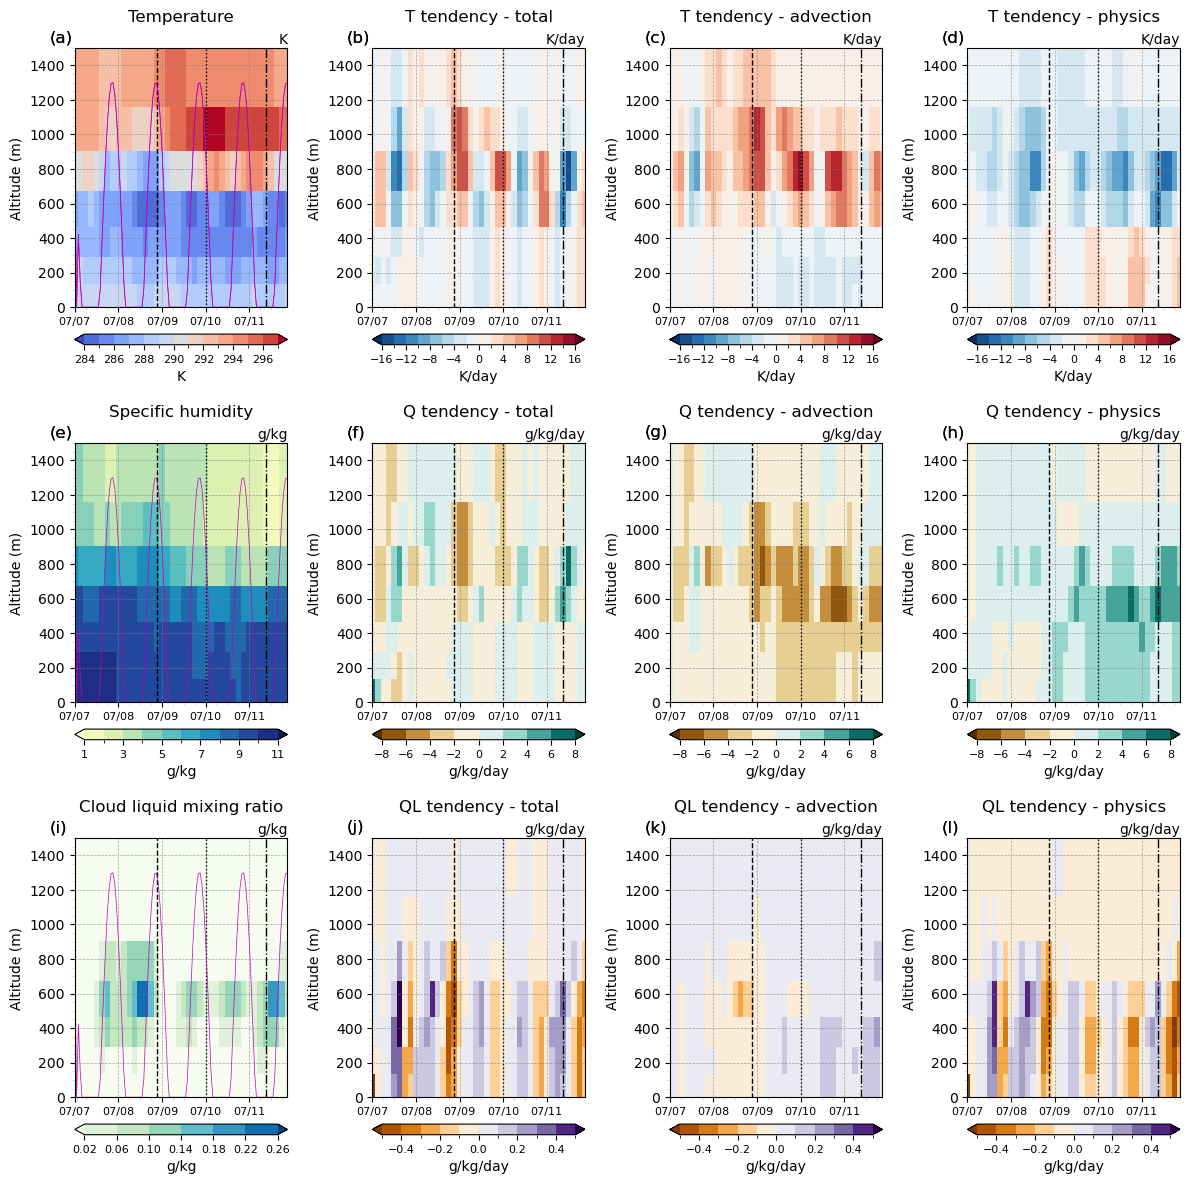

In [14]:
plot_cn_time_level_panel(ds_dict_tpdf, yy_dict_tpdf, var_group, opt_in_cn_tlev,
                        do_plot_time_vert_lines=True)

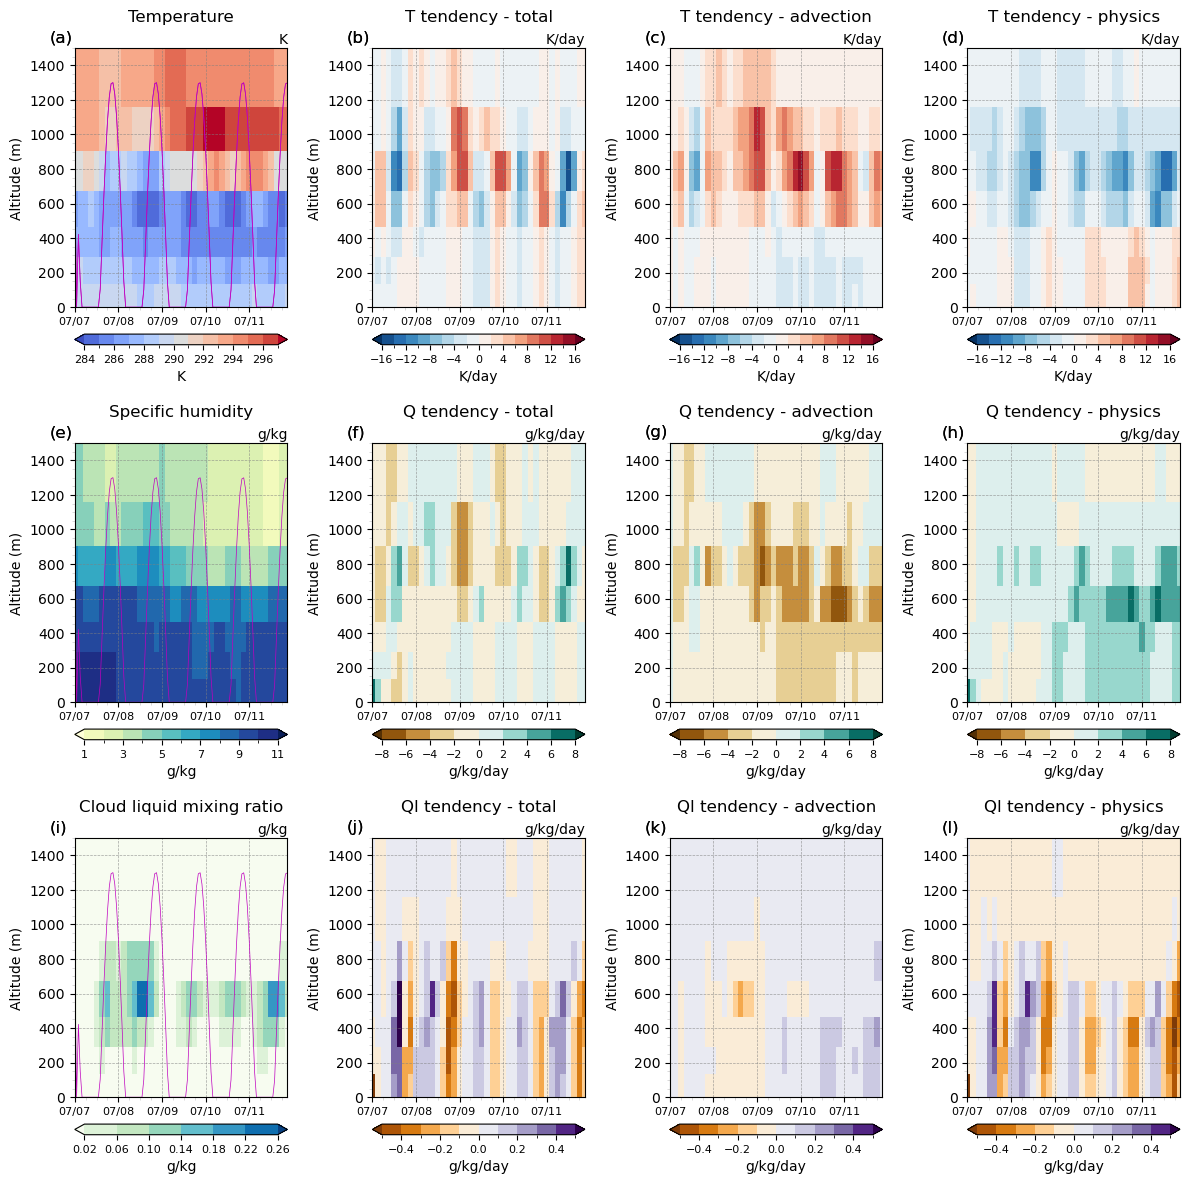

In [32]:
plot_cn_time_level_panel(ds_dict_tpdf, yy_dict_tpdf, var_group, opt_in_cn_tlev,
                        do_plot_time_vert_lines=False)